In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('customer-seg.csv')
df.head()

,CustomerID,Age,Gender,AnnualIncome,PurchaseFrequency,TotalSpending,PreferredCategory,LastPurchaseDaysAgo
0,C0001,56,Female,142418,7,3838,Home,61
1,C0002,69,Male,63088,18,2569,Clothing,138
2,C0003,46,Male,136868,27,16206,Electronics,50
3,C0004,32,Female,123196,34,17040,Clothing,259
4,C0005,60,Male,59811,27,9117,Groceries,107


In [25]:
df.shape

(500, 8)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   CustomerID           500 non-null    object
 1   Age                  500 non-null    int64 
 2   Gender               500 non-null    object
 3   AnnualIncome         500 non-null    int64 
 4   PurchaseFrequency    500 non-null    int64 
 5   TotalSpending        500 non-null    int64 
 6   PreferredCategory    500 non-null    object
 7   LastPurchaseDaysAgo  500 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 31.4+ KB


HANDLING MISSING VALUES

In [27]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
AnnualIncome,0
PurchaseFrequency,0
TotalSpending,0
PreferredCategory,0
LastPurchaseDaysAgo,0


In [28]:
df.drop_duplicates(inplace=True)

ENCODING CATEGORIES

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['PreferredCategory'] = le.fit_transform(df['PreferredCategory'])

SCALING THE DATA

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features = ['Age','AnnualIncome','PurchaseFrequency','TotalSpending']

scaled_data = scaler.fit_transform(df[features])

CREATING CLUSTER

In [31]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

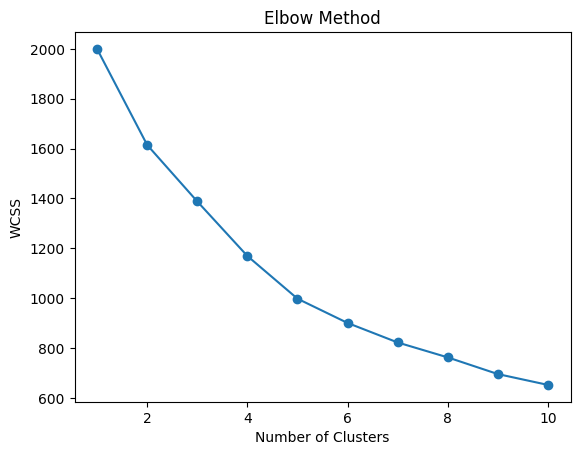

In [32]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [33]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)
df.head()

,CustomerID,Age,Gender,AnnualIncome,PurchaseFrequency,TotalSpending,PreferredCategory,LastPurchaseDaysAgo,Cluster
0,C0001,56,0,142418,7,3838,3,61,2
1,C0002,69,1,63088,18,2569,0,138,0
2,C0003,46,1,136868,27,16206,1,50,2
3,C0004,32,0,123196,34,17040,0,259,1
4,C0005,60,1,59811,27,9117,2,107,4


In [34]:
df['Cluster'].value_counts()

,count
Cluster,
4,122
3,103
2,100
0,98
1,77


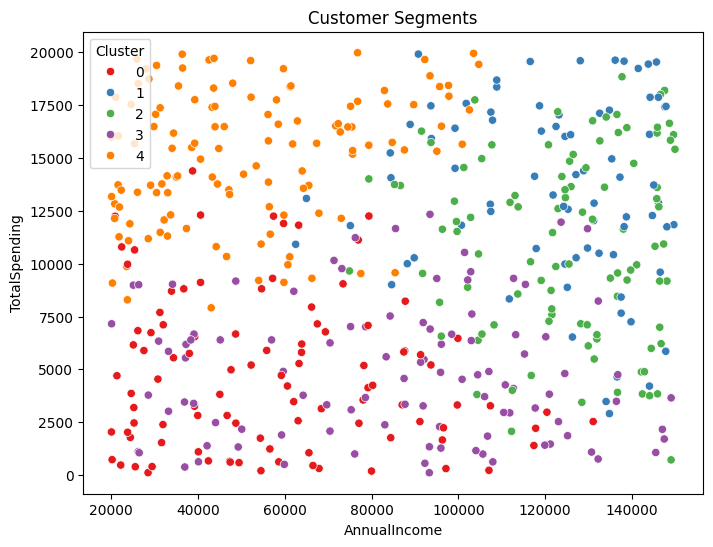

In [35]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='AnnualIncome',y='TotalSpending',hue='Cluster',palette='Set1')
plt.title("Customer Segments")
plt.show()

Business Insights
1. Customer Base Can Be Divided into Multiple Segments

The K-Means clustering algorithm successfully grouped customers into five distinct segments. This indicates that customers exhibit different purchasing behaviors and spending patterns, allowing the company to develop targeted marketing strategies rather than using a single approach for all customers.

2. High-Value Customers Can Be Identified

Some clusters contain customers with relatively higher spending levels and purchase frequencies. These customers contribute significantly to revenue and should be prioritized through loyalty programs, personalized recommendations, and exclusive offers.

3. Low-Spending Customers Present Growth Opportunities

Certain clusters show lower spending behavior. The company can encourage additional purchases through discounts, bundle offers, seasonal promotions, and targeted marketing campaigns.

4. Income and Spending Patterns Differ Across Segments

The analysis suggests that customers with similar income levels do not always exhibit the same spending behavior. This highlights the importance of segmentation rather than relying solely on income when making marketing decisions.

5. Personalized Marketing Can Improve Customer Engagement

Different customer groups have different characteristics. By tailoring promotions, product recommendations, and communication strategies to each segment, the company can improve customer satisfaction and increase conversion rates.

6. Resource Allocation Can Be Optimized

Customer segmentation enables the business to focus marketing resources on the most profitable customer groups while designing cost-effective campaigns for lower-value segments.

7. Data-Driven Decision Making

The clustering results provide management with a structured view of customer behavior, supporting informed decisions related to marketing, customer retention, and product positioning.